EJEMPLO 1: Conversión detallada

Conversión SAR ADC - 8 bits
Vin_diff = 3.700000 V
Vref = 5.0 V
LSB = 0.019531 V

Ciclo 1 (Bit 8):
  Vdac_test = 2.500000 V
  Vin >= Vdac → Bit = 1
  Vdac final = 2.500000 V
  Bits hasta ahora: 1

Ciclo 2 (Bit 7):
  Vdac_test = 3.750000 V
  Vin < Vdac → Bit = 0
  Vdac final = 2.500000 V
  Bits hasta ahora: 10

Ciclo 3 (Bit 6):
  Vdac_test = 3.125000 V
  Vin >= Vdac → Bit = 1
  Vdac final = 3.125000 V
  Bits hasta ahora: 101

Ciclo 4 (Bit 5):
  Vdac_test = 3.437500 V
  Vin >= Vdac → Bit = 1
  Vdac final = 3.437500 V
  Bits hasta ahora: 1011

Ciclo 5 (Bit 4):
  Vdac_test = 3.593750 V
  Vin >= Vdac → Bit = 1
  Vdac final = 3.593750 V
  Bits hasta ahora: 10111

Ciclo 6 (Bit 3):
  Vdac_test = 3.671875 V
  Vin >= Vdac → Bit = 1
  Vdac final = 3.671875 V
  Bits hasta ahora: 101111

Ciclo 7 (Bit 2):
  Vdac_test = 3.710938 V
  Vin < Vdac → Bit = 0
  Vdac final = 3.671875 V
  Bits hasta ahora: 1011110

Ciclo 8 (Bit 1):
  Vdac_test = 3.691406 V
  Vin >= Vdac → Bit 

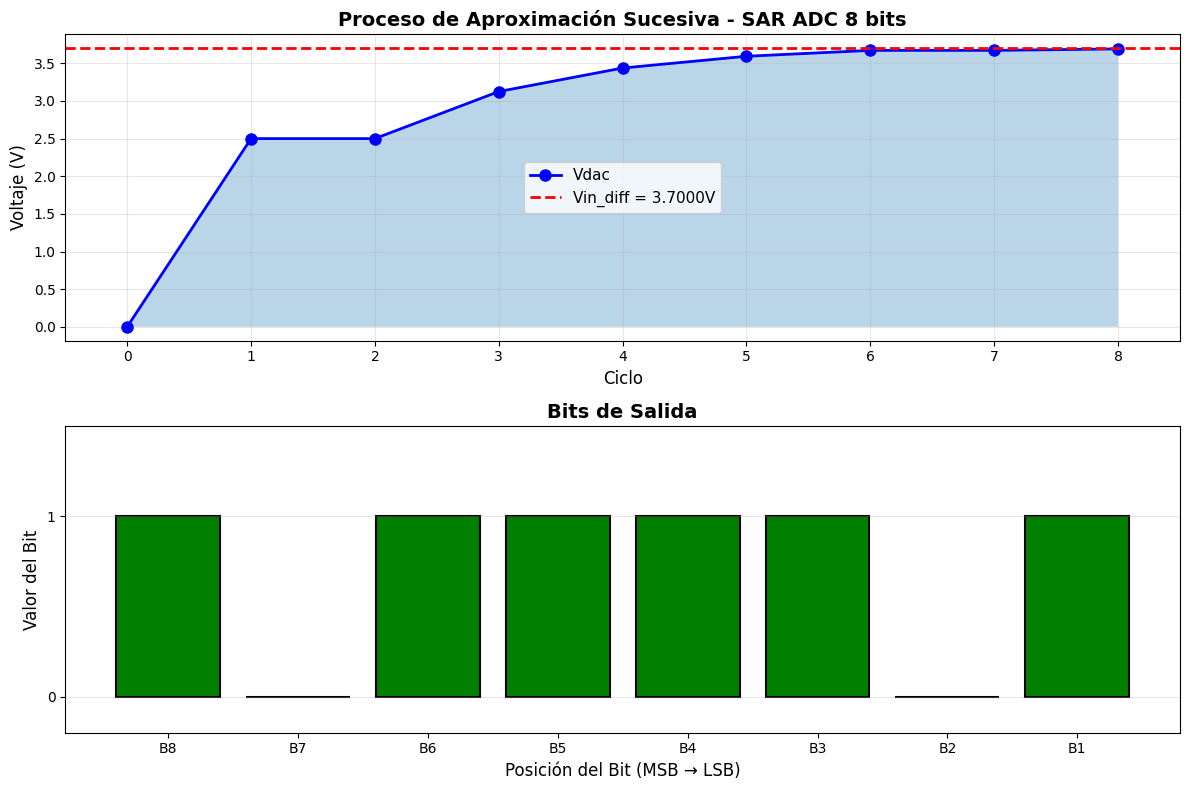

In [1]:
import numpy as np
import matplotlib.pyplot as plt

class SAR_ADC:
    def __init__(self, n_bits, vref):
        """
        Inicializa el SAR ADC
        
        Parámetros:
        - n_bits: número de bits de resolución
        - vref: voltaje de referencia (rango completo)
        """
        self.n_bits = n_bits
        self.vref = vref
        self.lsb = vref / (2**n_bits)  # Valor del LSB
        
    def convert(self, vin_diff, verbose=True):
        """
        Realiza la conversión SAR
        
        Parámetros:
        - vin_diff: voltaje de entrada diferencial a convertir
        - verbose: si True, muestra el proceso paso a paso
        
        Retorna:
        - bits: lista con los valores de cada bit (MSB a LSB)
        - digital_output: valor digital de salida
        """
        
        # Validar entrada
        if vin_diff < 0 or vin_diff > self.vref:
            print(f"⚠️  Advertencia: Vin_diff={vin_diff:.4f}V está fuera del rango [0, {self.vref}V]")
            vin_diff = np.clip(vin_diff, 0, self.vref)
        
        bits = []
        vdac = 0  # Voltaje inicial del DAC
        
        if verbose:
            print(f"\n{'='*60}")
            print(f"Conversión SAR ADC - {self.n_bits} bits")
            print(f"{'='*60}")
            print(f"Vin_diff = {vin_diff:.6f} V")
            print(f"Vref = {self.vref} V")
            print(f"LSB = {self.lsb:.6f} V")
            print(f"{'='*60}\n")
        
        # Proceso de aproximación sucesiva (MSB a LSB)
        for i in range(self.n_bits):
            # Probar con el bit actual en 1
            test_value = 2**(self.n_bits - i - 1)
            vdac_test = vdac + test_value * self.lsb
            
            # Comparación
            if vin_diff >= vdac_test:
                # Mantener el bit en 1
                bits.append(1)
                vdac = vdac_test
                comparacion = "Vin >= Vdac → Bit = 1"
            else:
                # Poner el bit en 0
                bits.append(0)
                comparacion = "Vin < Vdac → Bit = 0"
            
            if verbose:
                print(f"Ciclo {i+1} (Bit {self.n_bits-i}):")
                print(f"  Vdac_test = {vdac_test:.6f} V")
                print(f"  {comparacion}")
                print(f"  Vdac final = {vdac:.6f} V")
                print(f"  Bits hasta ahora: {''.join(map(str, bits))}")
                print()
        
        # Calcular valor digital de salida
        digital_output = sum([bit * 2**(self.n_bits-i-1) for i, bit in enumerate(bits)])
        
        if verbose:
            print(f"{'='*60}")
            print(f"Resultado Final:")
            print(f"  Código binario: {''.join(map(str, bits))}")
            print(f"  Valor decimal: {digital_output}")
            print(f"  Vdac final: {vdac:.6f} V")
            print(f"  Error de cuantización: {vin_diff - vdac:.6f} V ({abs(vin_diff-vdac)/self.lsb:.2f} LSB)")
            print(f"{'='*60}\n")
        
        return bits, digital_output
    
    def plot_conversion(self, vin_diff):
        """Visualiza gráficamente el proceso de conversión"""
        bits, _ = self.convert(vin_diff, verbose=False)
        
        # Reconstruir el proceso
        vdac_history = [0]
        vdac = 0
        
        for i, bit in enumerate(bits):
            test_value = 2**(self.n_bits - i - 1)
            if bit == 1:
                vdac += test_value * self.lsb
            vdac_history.append(vdac)
        
        # Crear gráfica
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
        
        # Gráfica del proceso de aproximación
        cycles = list(range(len(vdac_history)))
        ax1.plot(cycles, vdac_history, 'b-o', linewidth=2, markersize=8, label='Vdac')
        ax1.axhline(y=vin_diff, color='r', linestyle='--', linewidth=2, label=f'Vin_diff = {vin_diff:.4f}V')
        ax1.fill_between(cycles, vdac_history, alpha=0.3)
        ax1.set_xlabel('Ciclo', fontsize=12)
        ax1.set_ylabel('Voltaje (V)', fontsize=12)
        ax1.set_title(f'Proceso de Aproximación Sucesiva - SAR ADC {self.n_bits} bits', fontsize=14, fontweight='bold')
        ax1.grid(True, alpha=0.3)
        ax1.legend(fontsize=11)
        ax1.set_xlim(-0.5, len(vdac_history)-0.5)
        
        # Gráfica de los bits
        bit_positions = list(range(1, self.n_bits + 1))
        colors = ['green' if b == 1 else 'red' for b in bits]
        ax2.bar(bit_positions, bits, color=colors, edgecolor='black', linewidth=1.5)
        ax2.set_xlabel('Posición del Bit (MSB → LSB)', fontsize=12)
        ax2.set_ylabel('Valor del Bit', fontsize=12)
        ax2.set_title('Bits de Salida', fontsize=14, fontweight='bold')
        ax2.set_xticks(bit_positions)
        ax2.set_xticklabels([f'B{self.n_bits-i}' for i in range(self.n_bits)])
        ax2.set_ylim(-0.2, 1.5)
        ax2.set_yticks([0, 1])
        ax2.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()


# Ejemplo de uso
if __name__ == "__main__":
    # Crear un SAR ADC de 8 bits con Vref = 5V
    adc = SAR_ADC(n_bits=8, vref=5.0)
    
    # Ejemplo 1: Conversión con verbose
    vin = 3.7
    print("EJEMPLO 1: Conversión detallada")
    bits, digital_out = adc.convert(vin)
    
    # Ejemplo 2: Múltiples conversiones
    print("\n\nEJEMPLO 2: Múltiples conversiones")
    print(f"{'Vin (V)':<12} {'Binario':<12} {'Decimal':<10} {'Vdac (V)':<12}")
    print("-" * 50)
    
    test_voltages = [0.5, 1.25, 2.5, 3.75, 4.99]
    for v in test_voltages:
        bits, dec = adc.convert(v, verbose=False)
        vdac = sum([b * 2**(adc.n_bits-i-1) for i, b in enumerate(bits)]) * adc.lsb
        print(f"{v:<12.2f} {''.join(map(str, bits)):<12} {dec:<10} {vdac:<12.6f}")
    
    # Ejemplo 3: Visualización gráfica
    print("\n\nEJEMPLO 3: Visualización gráfica")
    adc.plot_conversion(3.7)